In [1]:
pip install shap

  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 561.7/561.7 kB 13.2 MB/s eta 0:00:00
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [shap]
Note: you may need to restart the kernel to use updated packages.


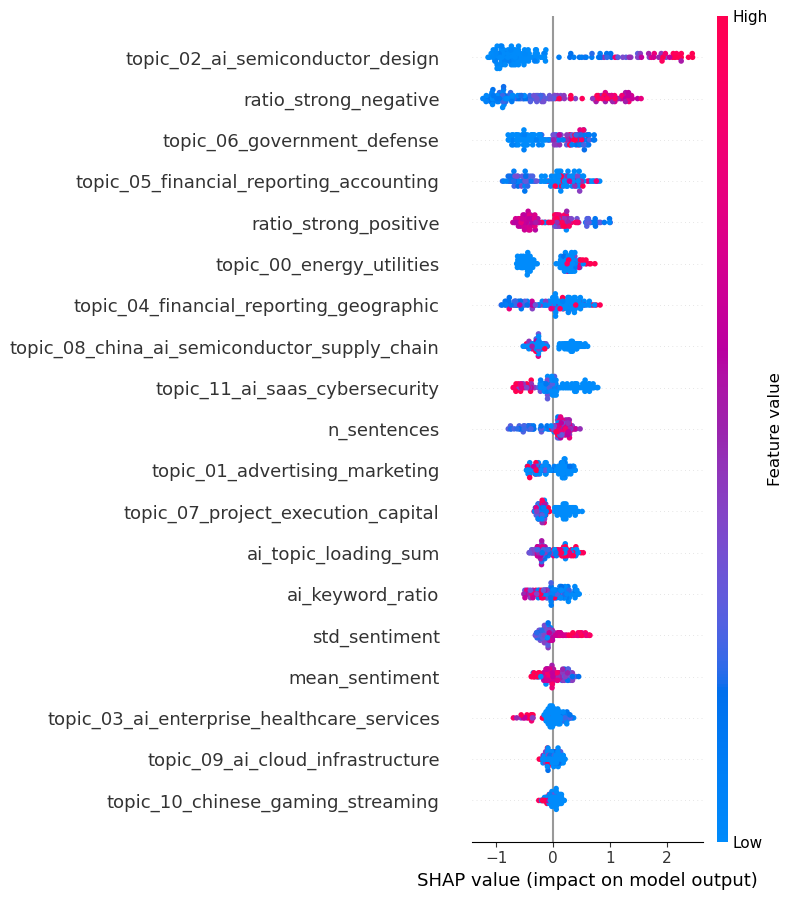

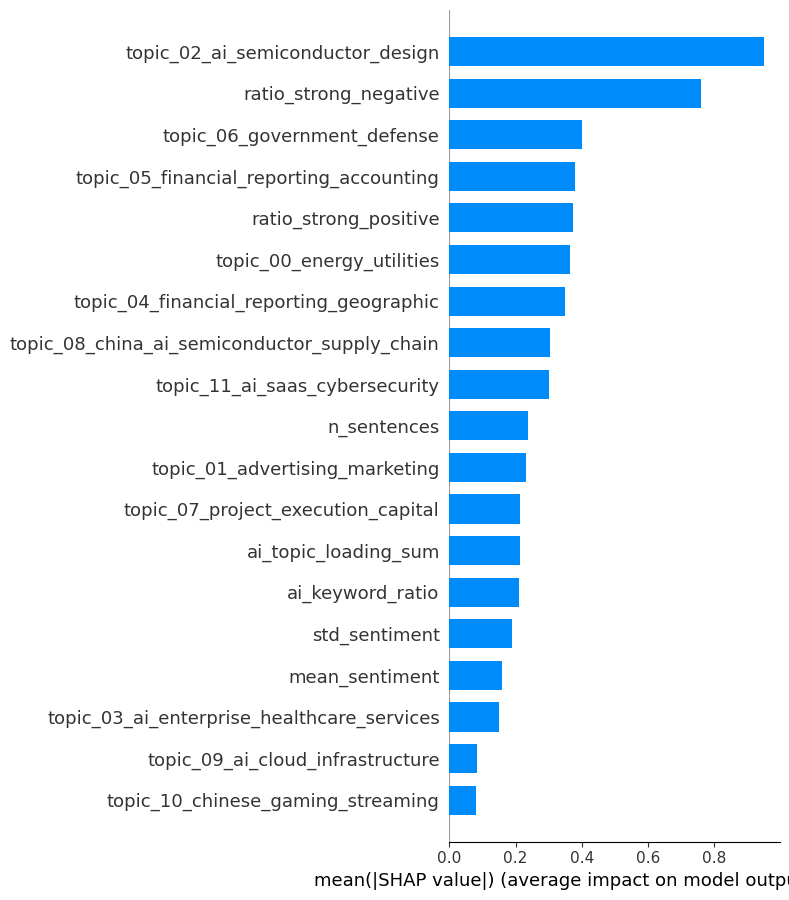

Saved:
  shap_summary_text_xgboost.png
  shap_bar_text_xgboost.png


In [2]:
# =========================
# SHAP for X_text_only + XGBoost
# =========================

import pandas as pd
import shap
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

# 1. Load data
df_text = pd.read_csv("model_text_only.csv")

# 2. Define features
drop_text_cols = {
    "companyid", "companyname", "company_name", "companyid_bridge",
    "ticker", "label", "label_binary", "title",
    "pct_positive", "pct_negative", "pct_neutral",
    "mean_p_positive", "mean_p_negative", "mean_p_neutral",
    "ai_keyword_count"
}
text_feature_cols = [
    c for c in df_text.columns
    if c not in drop_text_cols and not c.startswith("PC")
]

X_text = df_text[text_feature_cols].copy()
y_text = df_text["label_binary"].copy()

# 3. Impute missing values
imputer = SimpleImputer(strategy="median")
X_text_imp = pd.DataFrame(
    imputer.fit_transform(X_text),
    columns=text_feature_cols
)

# 4. Fit XGBoost
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_lambda=1.0,
    random_state=42,
    eval_metric="logloss"
)

xgb.fit(X_text_imp, y_text)

# 5. SHAP explainer
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_text_imp)

# 6. Summary plot
plt.figure()
shap.summary_plot(shap_values, X_text_imp, show=False)
plt.tight_layout()
plt.savefig("shap_summary_text_xgboost.png", dpi=300, bbox_inches="tight")
plt.show()

# 7. Bar plot
plt.figure()
shap.summary_plot(shap_values, X_text_imp, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("shap_bar_text_xgboost.png", dpi=300, bbox_inches="tight")
plt.show()

print("Saved:")
print("  shap_summary_text_xgboost.png")
print("  shap_bar_text_xgboost.png")